In [1]:
import pandas as pd
import numpy as np

In [2]:
# Memuat dataset dan mengubah '?' menjadi NaN agar terbaca sebagai missing value
df = pd.read_csv('/content/data_tugas 2.csv', na_values="?")

In [3]:
# Menampilkan 5 data teratas
df.head()

,normalized-losses,make,bahan-bakar,jumlah-pintu,body-style,wheel-bases,length,width,height
0,NaN,alfa-romero,gas,two,convertible,88.6,168.8,64.1,48.8
1,NaN,alfa-romero,gas,two,convertible,88.6,168.8,64.1,48.8
2,NaN,alfa-romero,gas,two,hatchback,94.5,171.2,65.5,52.4
3,164.0,audi,gas,four,sedan,99.8,176.6,66.2,54.3
4,164.0,audi,gas,four,sedan,99.4,176.6,66.4,54.3


**1. Menampilkan Jumlah Data Hilang**

In [4]:
# Menghitung missing value per kolom
missing_data = df.isnull().sum()

print("Jumlah Missing Value per Kolom:")
print(missing_data)

Jumlah Missing Value per Kolom:
normalized-losses    41
make                  4
bahan-bakar          13
jumlah-pintu         18
body-style           12
wheel-bases           3
length                8
width                 5
height                4
dtype: int64


**2. Mengganti Missing Value pada Variabel Kategori**

In [5]:
# Daftar variabel kategori
cat_cols = ['make', 'bahan-bakar', 'jumlah-pintu', 'body-style']

In [6]:
# Mengisi missing value dengan 'unknown'
for col in cat_cols:
    df[col] = df[col].fillna('unknown')

In [7]:
# Menampilkan ringkasan jumlah setiap kategori
for col in cat_cols:
    print(f"\nDistribusi Kategori pada {col}:")
    print(df[col].value_counts())


Distribusi Kategori pada make:
make
toyota           32
mazda            17
nissan           17
honda            13
mitsubishi       12
volkswagen       12
volvo            11
subaru           11
peugot           11
dodge             9
mercedes-benz     8
bmw               8
plymouth          7
audi              7
saab              6
porsche           4
unknown           4
isuzu             4
alfa-romero       3
chevrolet         3
jaguar            3
renault           2
mercury           1
Name: count, dtype: int64

Distribusi Kategori pada bahan-bakar:
bahan-bakar
gas        173
diesel      19
unknown     13
Name: count, dtype: int64

Distribusi Kategori pada jumlah-pintu:
jumlah-pintu
four       101
two         86
unknown     18
Name: count, dtype: int64

Distribusi Kategori pada body-style:
body-style
sedan          88
hatchback      67
wagon          24
unknown        12
hardtop         8
convertible     6
Name: count, dtype: int64


**3. Mengganti Missing Value pada Variabel Numerik**

In [8]:
# Daftar variabel numerik
num_cols = ['length', 'width', 'height']

In [9]:
# Imputasi dengan Mean
for col in num_cols:
    mean_val = df[col].mean()
    df[col] = df[col].fillna(mean_val)
    print(f"Rata-rata {col}: {mean_val:.2f} (Digunakan untuk mengisi data kosong)")

Rata-rata length: 173.90 (Digunakan untuk mengisi data kosong)
Rata-rata width: 65.93 (Digunakan untuk mengisi data kosong)
Rata-rata height: 53.74 (Digunakan untuk mengisi data kosong)


**4. Min-Max Normalization**

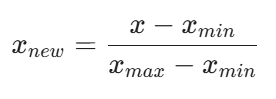

In [10]:
# Min-Max Normalization untuk wheel-bases
min_val = df['wheel-bases'].min()
max_val = df['wheel-bases'].max()

df['wheel-bases-normalized'] = (df['wheel-bases'] - min_val) / (max_val - min_val)

print("Hasil Min-Max Normalization pada wheel-bases (5 data pertama):")
print(df[['wheel-bases', 'wheel-bases-normalized']].head())

Hasil Min-Max Normalization pada wheel-bases (5 data pertama):
   wheel-bases  wheel-bases-normalized
0         88.6                0.058309
1         88.6                0.058309
2         94.5                0.230321
3         99.8                0.384840
4         99.4                0.373178


**5. Z-Score Normalization**

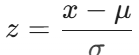

In [11]:
# Z-Score Normalization untuk length, width, dan height
for col in ['length', 'width', 'height']:
    mu = df[col].mean()
    sigma = df[col].std()
    df[f'{col}-zscore'] = (df[col] - mu) / sigma

print("Hasil Z-Score Normalization (5 data pertama):")
print(df[['length-zscore', 'width-zscore', 'height-zscore']].head())

Hasil Z-Score Normalization (5 data pertama):
   length-zscore  width-zscore  height-zscore
0      -0.428526     -0.867630      -2.038094
1      -0.428526     -0.867630      -2.038094
2      -0.226967     -0.204232      -0.552035
3       0.226541      0.127467       0.232274
4       0.226541      0.222238       0.232274
